In [1]:
!pip install opencv-python matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

In [3]:
!wget -O img1.png https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left01.jpg
!wget -O img2.png https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left02.jpg

--2026-06-26 13:07:01--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left01.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27908 (27K) [image/jpeg]
Saving to: ‘img1.png’

img1.png            100%[===================>]  27.25K  --.-KB/s    in 0.002s  

2026-06-26 13:07:01 (15.4 MB/s) - ‘img1.png’ saved [27908/27908]

--2026-06-26 13:07:01--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left02.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28611 (28K) [image/jpeg]
Saving to: ‘

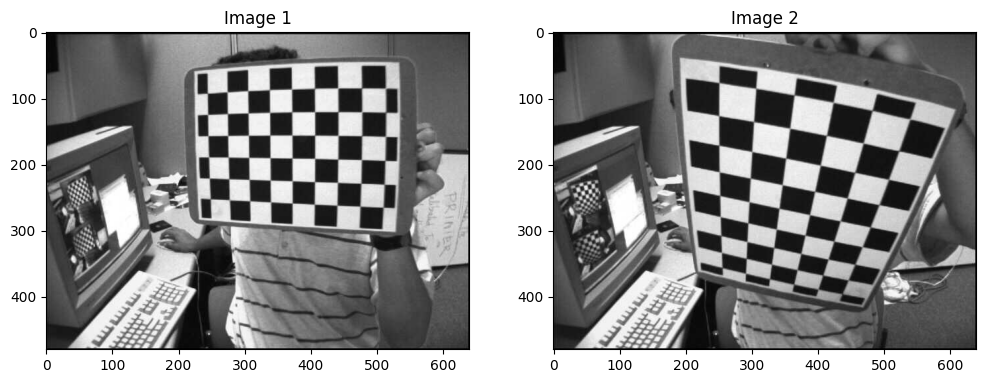

In [4]:
img1 = cv2.imread("img1.png")
img2 = cv2.imread("img2.png")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Image 1")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Image 2")

plt.show()

In [5]:
orb = cv2.ORB_create(3000)

kp1, des1 = orb.detectAndCompute(gray1,None)
kp2, des2 = orb.detectAndCompute(gray2,None)

print("Keypoints Image 1:", len(kp1))
print("Keypoints Image 2:", len(kp2))

Keypoints Image 1: 3000
Keypoints Image 2: 3000


In [6]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.match(des1,des2)

matches = sorted(matches,key=lambda x:x.distance)

print("Matches:",len(matches))

Matches: 3000


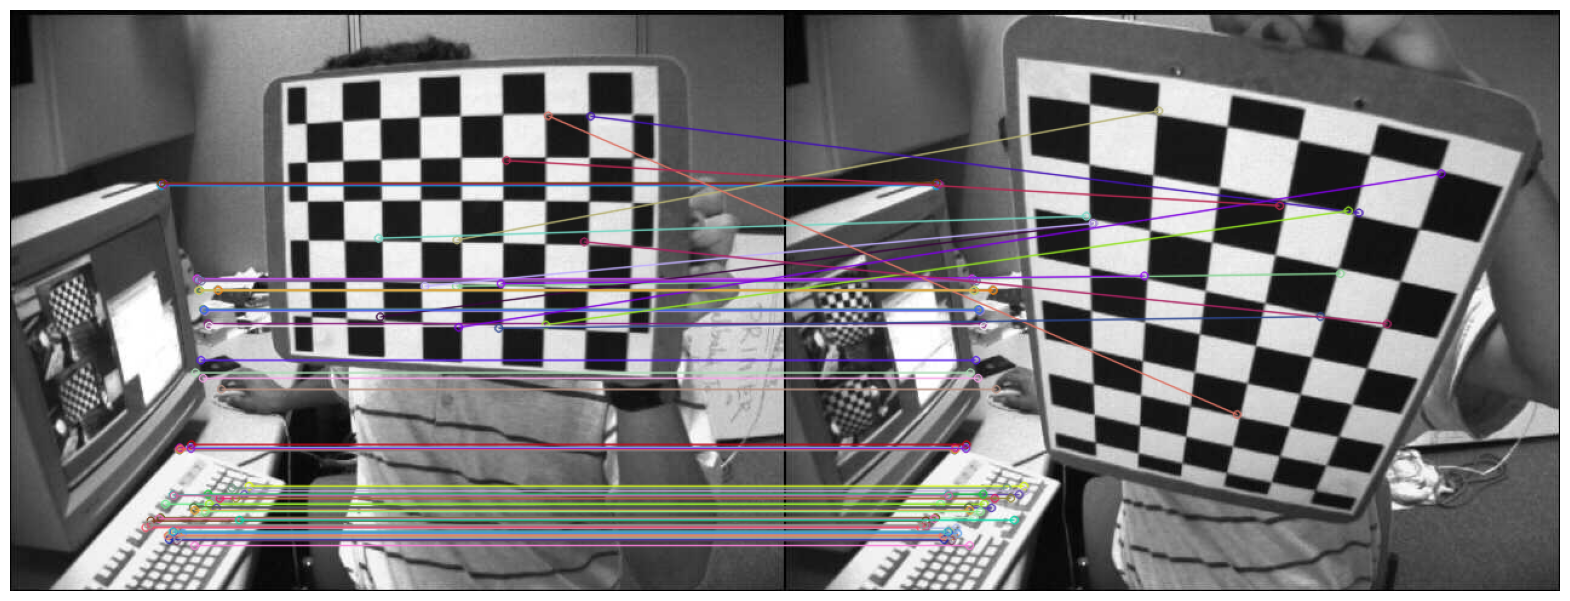

In [7]:
match_img = cv2.drawMatches(
    img1,kp1,
    img2,kp2,
    matches[:80],
    None,
    flags=2
)

plt.figure(figsize=(20,10))
plt.imshow(cv2.cvtColor(match_img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [8]:
focal = 718.856

cx = img1.shape[1]/2
cy = img1.shape[0]/2

K = np.array([
    [focal,0,cx],
    [0,focal,cy],
    [0,0,1]
])

K

array([[718.856,   0.   , 320.   ],
       [  0.   , 718.856, 240.   ],
       [  0.   ,   0.   ,   1.   ]])

In [9]:
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])

pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

pts1.shape

(3000, 2)

In [10]:
E, mask = cv2.findEssentialMat(
    pts1,
    pts2,
    K,
    method=cv2.RANSAC,
    prob=0.999,
    threshold=1.0
)

print(E)

[[ 6.86364758e-04  7.00377560e-01 -8.77156014e-02]
 [-7.00369020e-01  5.57712780e-04 -4.30113434e-02]
 [ 8.74015072e-02  4.20796024e-02  8.62188970e-05]]


In [11]:
_, R, t, mask = cv2.recoverPose(
    E,
    pts1,
    pts2,
    K
)

print("Rotation Matrix")
print(R)

print()

print("Translation Vector")
print(t)

Rotation Matrix
[[ 9.99998906e-01 -8.26294481e-04  1.22721483e-03]
 [ 8.26906366e-04  9.99999534e-01 -4.98172629e-04]
 [-1.22680262e-03  4.99186875e-04  9.99999123e-01]]

Translation Vector
[[-0.05961167]
 [ 0.12355524]
 [ 0.99054558]]


In [12]:
P1 = np.hstack((np.eye(3), np.zeros((3,1))))

P1 = K @ P1

P2 = np.hstack((R,t))

P2 = K @ P2

In [13]:
points4D = cv2.triangulatePoints(
    P1,
    P2,
    pts1.T,
    pts2.T
)

points3D = points4D[:3] / points4D[3]

points3D.shape

(3, 3000)

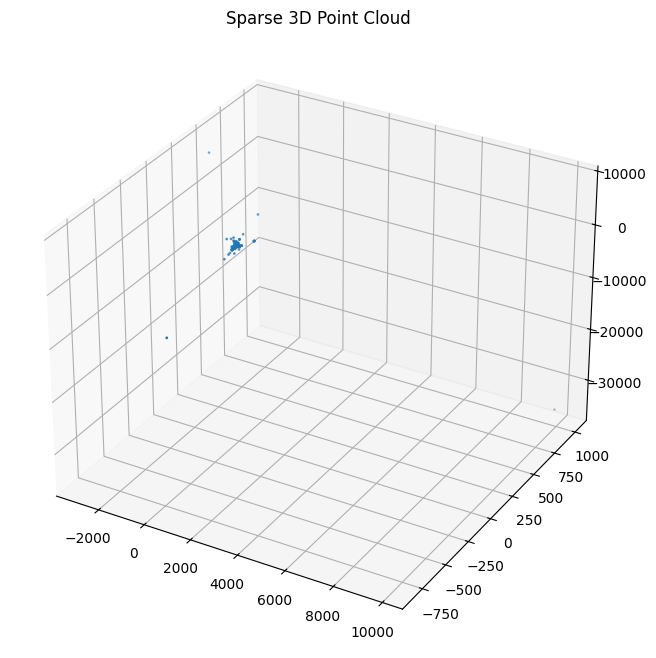

In [14]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(
    points3D[0],
    points3D[1],
    points3D[2],
    s=1
)

ax.set_title("Sparse 3D Point Cloud")

plt.show()

In [15]:
print("Tiny Structure from Motion Completed!")

print()

print("Detected Features :",len(kp1))

print("Feature Matches :",len(matches))

print("Estimated Camera Motion")

print("Generated Sparse 3D Point Cloud")

Tiny Structure from Motion Completed!

Detected Features : 3000
Feature Matches : 3000
Estimated Camera Motion
Generated Sparse 3D Point Cloud
